<a href="https://colab.research.google.com/github/DJCordhose/buch-machine-learning-notebooks/blob/master/pytorch/kap7-iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kapitel 7: Neuronale Netzwerke - Grundlagen

In [31]:
import warnings
# warnings.filterwarnings('ignore')

In [32]:
import matplotlib.pylab as plt
import numpy as np

In [33]:
colors = 'bwr'#['b','y','r']
CMAP = colors#plt.cm.rainbow

In [34]:
import sklearn
print(sklearn.__version__)

1.6.1


In [35]:
import pandas as pd
print(pd.__version__)

2.2.3


In [36]:
import sys
if 'google.colab' in sys.modules:
    !pip install -q torchinfo

## Iris mit Neuronalen Netzwerken

In [37]:
from sklearn.datasets import load_iris
iris = load_iris()

In [38]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

array([[<Axes: xlabel='sepal length (cm)', ylabel='sepal length (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='sepal length (cm)'>,
        <Axes: xlabel='petal length (cm)', ylabel='sepal length (cm)'>,
        <Axes: xlabel='petal width (cm)', ylabel='sepal length (cm)'>],
       [<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='sepal width (cm)'>,
        <Axes: xlabel='petal length (cm)', ylabel='sepal width (cm)'>,
        <Axes: xlabel='petal width (cm)', ylabel='sepal width (cm)'>],
       [<Axes: xlabel='sepal length (cm)', ylabel='petal length (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='petal length (cm)'>,
        <Axes: xlabel='petal length (cm)', ylabel='petal length (cm)'>,
        <Axes: xlabel='petal width (cm)', ylabel='petal length (cm)'>],
       [<Axes: xlabel='sepal length (cm)', ylabel='petal width (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='petal width (cm)'>,
  

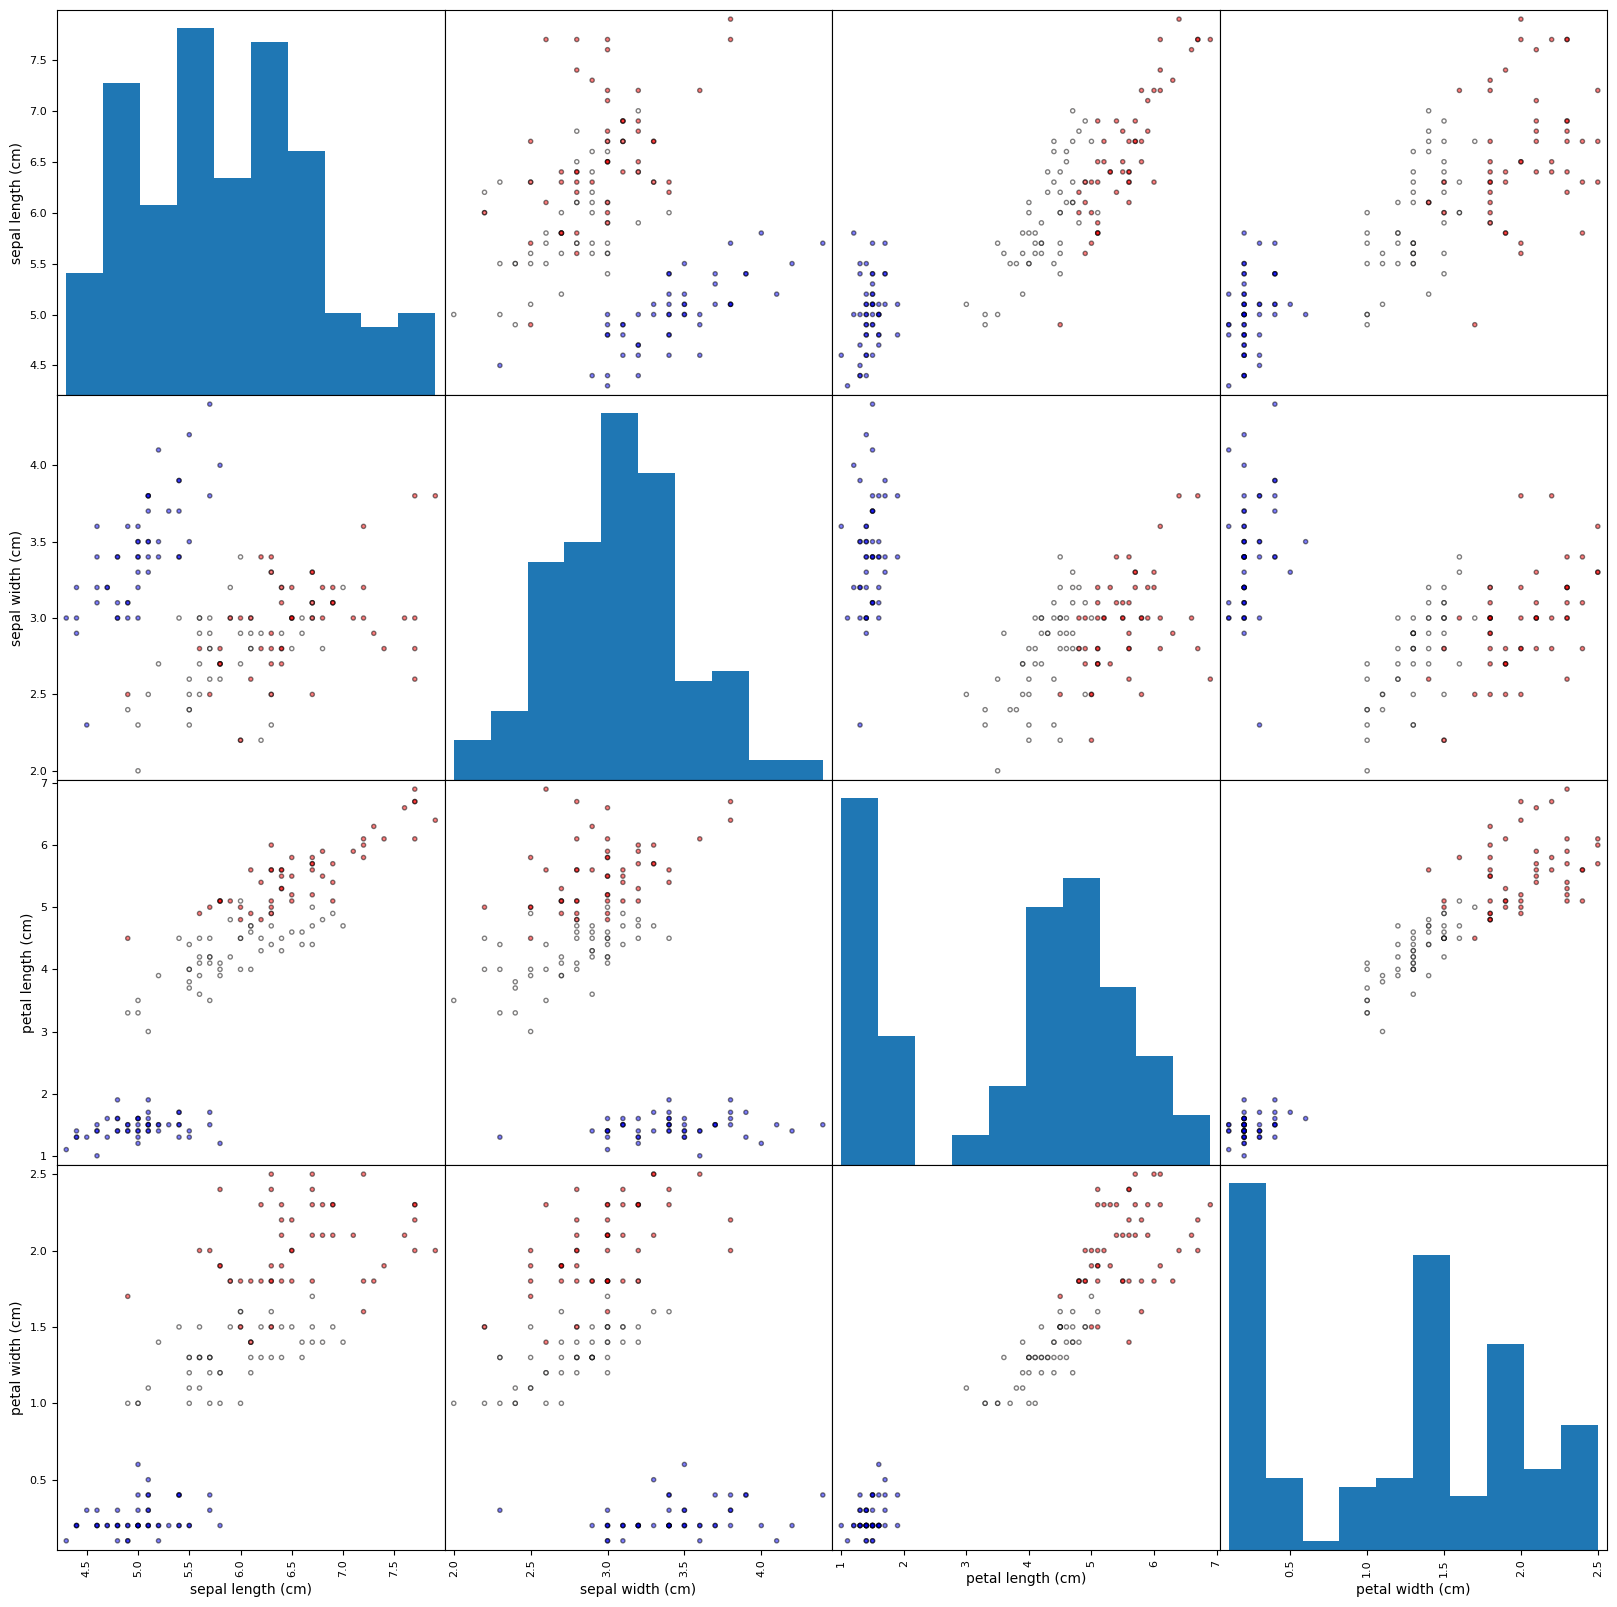

In [39]:
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
# pd.plotting.scatter_matrix(iris_df, c=iris.target, cmap=CMAP, edgecolor='black', figsize=(20, 20))
### JWL: Obacht: hier kommt es zu einem TypeError
### JWL: Dieser verschwindet, wenn man 'edgecolor' zu 'edgecolors' ändert.
pd.plotting.scatter_matrix(iris_df, c=iris.target, cmap=CMAP, edgecolors='black', figsize=(20, 20))

In [40]:
# plt.savefig('ML_0701.png', bbox_inches='tight')

## Das künstliche Neuron

In [41]:
w0 = 3
w1 = -4
w2 = 2

def neuron_no_activation(x1, x2):
    sum = w0 + x1 * w1 + x2 * w2
    return sum

In [42]:
iris.data[0]

array([5.1, 3.5, 1.4, 0.2])

In [43]:
neuron_no_activation(5.1, 3.5)

-10.399999999999999

### Activation Functions

In [44]:
def centerAxis(uses_negative=False):
    # http://matplotlib.org/api/pyplot_api.html#matplotlib.pyplot.plot
    ax = plt.gca()
    ax.spines['left'].set_position('center')
    if uses_negative:
        ax.spines['bottom'].set_position('center')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')

#### Step Function: abrupter, nicht stetig differenzierbarer Übergang zwischen 0 und 1

In [45]:
def np_step(X):
    return 0.5 * (np.sign(X) + 1)

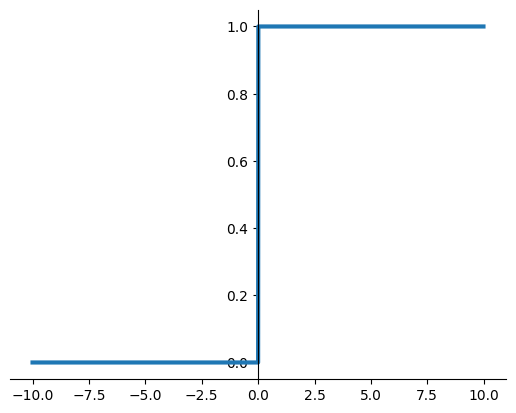

In [46]:
x = np.arange(-10,10,0.01)
y = np_step(x)

centerAxis()
plt.plot(x, y, lw=3)

#### Sigmoid Function: Fließender Übergang zwischen 0 und 1

In [47]:
def np_sigmoid(X):
    return 1 / (1 + np.exp(X * -1))

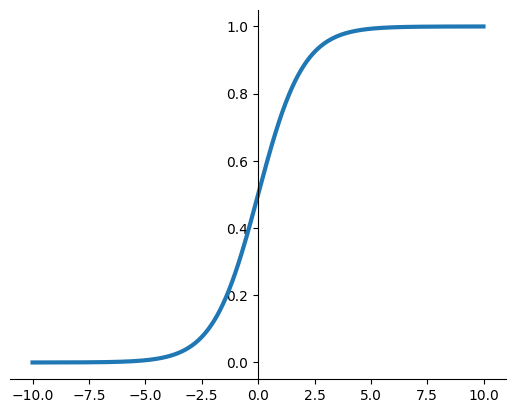

In [48]:
x = np.arange(-10,10,0.01)
y = np_sigmoid(x)

centerAxis()
plt.plot(x,y,lw=3)

#### Tangens Hyperbolicus Function: Fließender Übergang zwischen -1 und 1

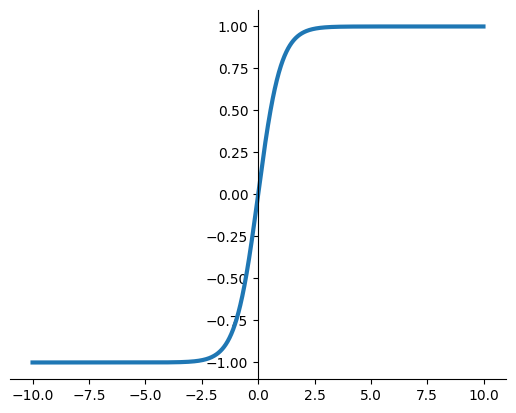

In [49]:
x = np.arange(-10,10,0.01)
y = np.tanh(x)

centerAxis()
plt.plot(x,y,lw=3)

#### Relu: Einfach zu berechnen, setzt kompletten negativen Wertebereich auf 0

In [50]:
def np_relu(x):
    return np.maximum(0, x)

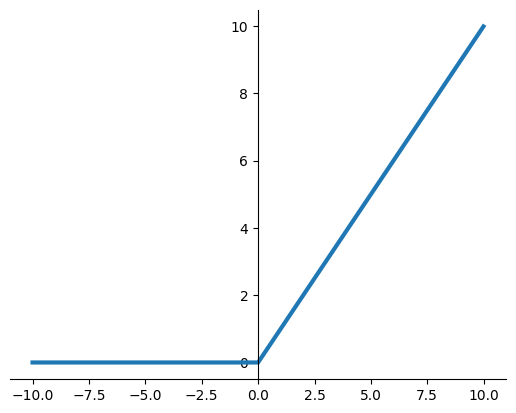

In [51]:
x = np.arange(-10,10,0.01)
y = np_relu(x)

centerAxis()
plt.plot(x,y,lw=3)

In [52]:
# https://docs.python.org/3/library/math.html
import math as math
def sigmoid(x):
    return 1 / (1 + math.exp(x * -1))

w0 = 3
w1 = -4
w2 = 2

def neuron(x1, x2):
    sum = w0 + x1 * w1 + x2 * w2
    return sigmoid(sum)

In [53]:
neuron(5.1, 3.5)

3.043155690056538e-05

In [54]:
# Version that takes as many values as you like
weights_with_bias = np.array([3, -4, 2])
def np_neuron(X):
    inputs_with_1_for_bias = np.concatenate((np.array([1]), X))
    return np_sigmoid(np.sum(inputs_with_1_for_bias*weights_with_bias));

In [55]:
np_neuron(np.array([5.1, 3.5]))

np.float64(3.043155690056538e-05)

## Unser erstes neuronales Netzwerk mit PyTorch

In [56]:
# Ein minimales neuronales Netzwerk mit PyTorch definieren:
# Eingabe: 4 Features, Ausgabe: 3 Logits
import torch
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(4, 3)
)

In [57]:
# Beispiel-Datenpunkt definieren
# (entspricht dem ersten Eintrag des Iris-Datensatzes)
sample = torch.tensor([[5.1, 3.5, 1.4, 0.2]])

In [58]:
# Modellzusammenfassung ausgeben
from torchinfo import summary

summary(
    model,
    input_size=(sample.shape),
    col_names=("input_size", "output_size"),
)

Layer (type:depth-idx)                   Input Shape               Output Shape
Sequential                               [1, 4]                    [1, 3]
├─Linear: 1-1                            [1, 4]                    [1, 3]
Total params: 15
Trainable params: 15
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [59]:
# Modell mit unseremn Beispieldaten testen:
logits = model(sample)
print(logits)

tensor([[-2.9349,  0.4113,  0.3314]], grad_fn=<AddmmBackward0>)


In [60]:
# Vorhergesagte Klasse ausgeben:
predicted_class = torch.argmax(logits, dim=1)
print(predicted_class)

tensor([1])


# Training

In [61]:
# Iris-Datensatz laden
from sklearn.datasets import load_iris
iris = load_iris()

In [62]:
# Daten und Labels extrahieren:
X = torch.tensor(iris.data,   dtype=torch.float32)
y = torch.tensor(iris.target, dtype=torch.long)

print('X.shape: ', X.shape) # Features
print('y.shape: ', y.shape) # Labels/Targets

X.shape:  torch.Size([150, 4])
y.shape:  torch.Size([150])


In [63]:
# Datensatz in Trainings- und Testdaten aufteilen:
from sklearn.model_selection import train_test_split

(
    X_train,             # Features für das Training
    X_test,              # Features für die spätere Evaluation
    y_train,             # Labels/Targets für das Training
    y_test,              # Labels/Targets für das Testing
) = train_test_split(
    X,                   # alle Features
    y,                   # alle Labels/Targets
    test_size=0.2,       # 20 % der Daten werden Testdaten
    random_state=42,     # reproduzierbare Aufteilung
    stratify=y,          # Konsistenz für Klassenverteilung
                         # in Train- und Testdaten
)

print('Features (Train): ', X_train.shape)
print('Features (Test):  ', X_test.shape)
print('Labels   (Train): ', y_train.shape)
print('Labels   (Test):  ', y_test.shape)

Features (Train):  torch.Size([120, 4])
Features (Test):   torch.Size([30, 4])
Labels   (Train):  torch.Size([120])
Labels   (Test):   torch.Size([30])


In [64]:
# Optimizer definieren
optimizer = torch.optim.Adam(
    model.parameters(), # liefert die Gewichte, die der Optimizer anpassen soll.
)

# Loss-Funktion angeben
loss_function    = nn.CrossEntropyLoss()

In [65]:
# Die eigentliche Trainingsschleife (endlich!):
epochs = 500 # Anzahl Schleifendurdchläufe
losses = []  # Speicher für Loss-Werte

# Schleife ausführen:
for epoch in range(epochs):
    model.train()                    # Trainingsmodus aktivieren
    outputs = model(X_train)         # Forward-Pass
    loss = loss_function(
                outputs, y_train)    # Loss berechnen
    optimizer.zero_grad()            # alte Gradienten zurücksetzen
    loss.backward()                  # Rückpropagation
    optimizer.step()                 # Gewichte aktualisieren
    losses.append(loss.item())       # Loss pro Epoche speichern

In [66]:
# Losses ausgeben:
print(losses)

[2.141209363937378, 2.129176139831543, 2.117293357849121, 2.1055660247802734, 2.093998432159424, 2.082595109939575, 2.071359395980835, 2.060295581817627, 2.049405813217163, 2.0386924743652344, 2.0281567573547363, 2.017798900604248, 2.0076184272766113, 1.9976125955581665, 1.9877792596817017, 1.9781131744384766, 1.9686092138290405, 1.9592607021331787, 1.9500606060028076, 1.9410029649734497, 1.9320801496505737, 1.9232860803604126, 1.9146145582199097, 1.9060605764389038, 1.8976194858551025, 1.8892861604690552, 1.8810566663742065, 1.8729274272918701, 1.8648946285247803, 1.85695481300354, 1.849104642868042, 1.8413407802581787, 1.8336602449417114, 1.826060175895691, 1.8185372352600098, 1.811089038848877, 1.8037123680114746, 1.7964051961898804, 1.7891641855239868, 1.7819876670837402, 1.77487313747406, 1.767818570137024, 1.7608215808868408, 1.7538810968399048, 1.7469947338104248, 1.7401617765426636, 1.7333799600601196, 1.7266489267349243, 1.719967007637024, 1.7133338451385498, 1.706748485565185

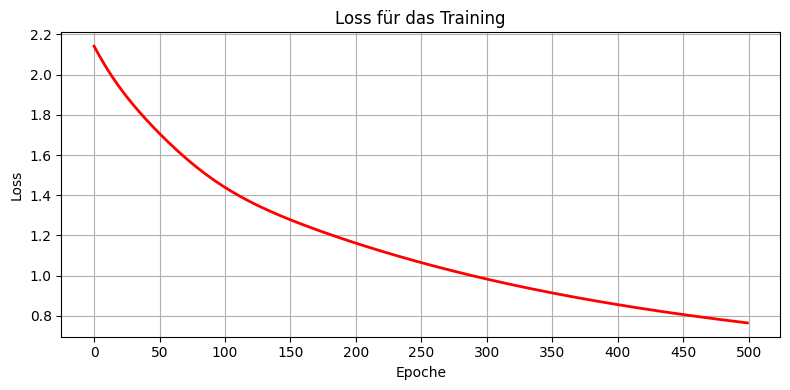

In [67]:
# Losses als Grafik ausgeben:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(losses, linewidth=2, color="red")

plt.title("Loss für das Training")
plt.xlabel("Epoche")
plt.ylabel("Loss")

plt.xticks(range(0, 501, 50))  # Rasterlinien bei 0, 50, 100, ..., 500
plt.grid(True)

plt.tight_layout()
plt.show()

# Bewertung

In [68]:
# Modell in den Auswertungsmodus versetzen und mit
# den Beispieldaten (sample) testen:
model.eval()
with torch.no_grad():
    logits = model(sample)

In [69]:
# Logits ausgeben:
print( logits )

tensor([[-0.7972, -1.6374, -2.1244]])


In [70]:
# Vorhergesagte Klasse ausgeben:
predicted_class = torch.argmax(logits, dim=1)
print(iris.target_names[predicted_class])

setosa


In [71]:
# Probe anhand des tatsächlichen Klasse
# (erster Eintrag im Iris-Datensatz):
print(iris.target_names[y[0]])

setosa


### Wo ist die Accuracy-Funktion?
Die Funktion zur Berechnung der Accuracy und ihre Anwendung findest Du im Abschnitt "Der vollständige Code".

# Der vollständige Code

Hier findest Du den Code aus dem Abschnitt zu __Feed Forward Networks__ noch einmal komplett

Logits für Sample vor Training: tensor([[-2.0086, -3.5702, -1.6896]])
Vorhergesagte Klasse für Sample vor Training: tensor([2])
X.shape:  torch.Size([150, 4])
y.shape:  torch.Size([150])
Features (Train):  torch.Size([120, 4])
Features (Test):   torch.Size([30, 4])
Labels   (Train):  torch.Size([120])
Labels   (Test):   torch.Size([30])
Accuracy (vor Training - _train): 0.3333333432674408
Accuracy (vor Training - _test) : 0.3333333432674408
Accuracy (nach Training - _train): 0.7749999761581421
Accuracy (nach Training - _test) : 0.7666666507720947
Losses: [1.2898441553115845, 1.2792574167251587, 1.2687653303146362, 1.2583705186843872, 1.248075246810913, 1.2378829717636108, 1.227795958518982, 1.2178168296813965, 1.2079476118087769, 1.198191523551941, 1.1885502338409424, 1.1790262460708618, 1.169621229171753, 1.1603374481201172, 1.1511768102645874, 1.1421408653259277, 1.133231282234192, 1.124449372291565, 1.115796685218811, 1.1072742938995361, 1.0988831520080566, 1.090624451637268, 1.0824

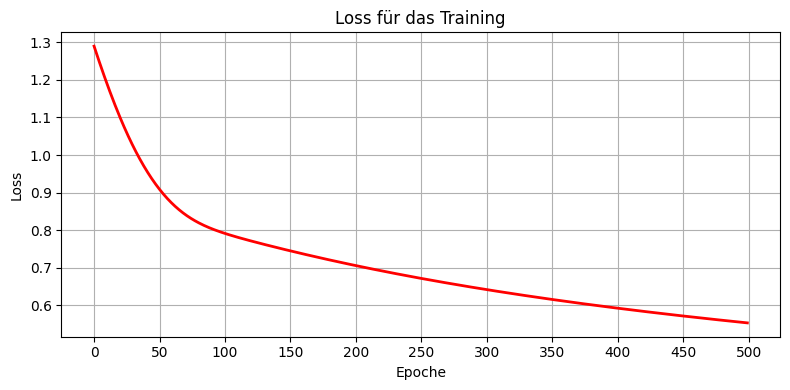

Logits für Sample nach Training: tensor([[-0.4776, -2.3425, -3.0334]])
Vorhergesagte Klasse nach Training: setosa
Verifizierung der Klasse: setosa


In [72]:
### Zur Sicherheit etwas Notebook-Magic:
### Alle Variablen aus vorigen Zellen zurücksetzen
### (Dies ist KEIN Neustart des Python-Kernels!)
%reset -f


# Iris mit neuronalen Netzen
import torch
import torch.nn as nn
from torchinfo import summary

# Für reproduzierbare Ergebnisse Zufallsfunktion
# ausdrücklich initialisieren:
torch.manual_seed(666)

# Hier wird das Netzwerk definiert:
# Vier Eingaben (die Features),
# drei Ausgaben (entsprechend den Iris-Arten)
model = nn.Sequential(
    nn.Linear(4, 3),
)

# Beispiel-Tensor zum Testen definieren
# (entspricht dem ersten Eintrag im Iris-Datensatz)
sample = torch.tensor([[5.1, 3.5, 1.4, 0.2]])
# logits = model(sample)
# print(logits)

# Modellbeschreibung ausgeben:
summary(
    model,
    input_size=(sample.shape),
    col_names=("input_size", "output_size"),
)

# Erste Vorhersage mit untrainiertem Modell
# 'sample' ist unser oben defnierter Beispiel-Tensor
with torch.no_grad():
    logits = model(sample)

# Logits ausgeben:
print(f"Logits für Sample vor Training: {logits}")

# Vorhergesagte Klasse ohne Training:
predicted_class = torch.argmax(logits, dim=1)
print(f"Vorhergesagte Klasse für Sample vor Training: {predicted_class}")

# Iris-Datensatz laden
from sklearn.datasets import load_iris
iris = load_iris()

# Daten und Labels extrahieren:
X = torch.tensor(iris.data,   dtype=torch.float32)
y = torch.tensor(iris.target, dtype=torch.long)

print('X.shape: ', X.shape) # Features
print('y.shape: ', y.shape) # Labels/Targets

# Datensatz in Trainings- und Testdaten aufteilen:
from sklearn.model_selection import train_test_split

(
    X_train,             # Features für das Training
    X_test,              # Features für die spätere Evaluation
    y_train,             # Labels/Targets für das Training
    y_test,              # Labels/Targets für das Testing
) = train_test_split(
    X,                   # alle Features
    y,                   # alle Labels/Targets
    test_size=0.2,       # 20 % der Daten werden Testdaten
    random_state=42,     # reproduzierbare Aufteilung
    stratify=y,          # Konsistenz für Klassenverteilung
                         # in Train- und Testdaten
)

print('Features (Train): ', X_train.shape)
print('Features (Test):  ', X_test.shape)
print('Labels   (Train): ', y_train.shape)
print('Labels   (Test):  ', y_test.shape)

# Optimizer definieren
optimizer = torch.optim.Adam(
    model.parameters(), # liefert die Gewichte, die der Optimizer anpassen soll.
)

# Loss-Funktion angeben
loss_function    = nn.CrossEntropyLoss()


## Funktion zur Berechnung der Accuracy:
def calculate_accuracy(data, target, text=''):
    model.eval()

    with torch.no_grad():
        logits              = model(data)                   # 1
        predictions         = torch.argmax(logits, dim=1)   # 2
        correct_predictions = (predictions == target)       # 3
        number_correct      = correct_predictions.sum()     # 4
        number_total        = target.shape[0]               # 5
        accuracy            = number_correct / number_total # 6

        print(f"Accuracy {text}:", accuracy.item())         # 7

# Accuracy vor dem Training berechnen und ausgeben:
calculate_accuracy(X_train, y_train,'(vor Training - _train)')
calculate_accuracy(X_test,  y_test, '(vor Training - _test) ')

# Die eigentliche Trainingsschleife (endlich!):
epochs = 500 # Anzahl Schleifendurdchläufe
losses = []  # Speicher für Loss-Werte

# Schleife ausführen:
for epoch in range(epochs):
    model.train()                    # Trainingsmodus aktivieren
    outputs = model(X_train)         # Forward-Pass
    loss = loss_function(
                outputs, y_train)    # Loss berechnen
    optimizer.zero_grad()            # alte Gradienten zurücksetzen
    loss.backward()                  # Rückpropagation
    optimizer.step()                 # Gewichte aktualisieren
    losses.append(loss.item())       # Loss pro Epoche speichern

# Accuracy nach dem Training berechnen und ausgeben:
calculate_accuracy(X_train, y_train,'(nach Training - _train)')
calculate_accuracy(X_test,  y_test, '(nach Training - _test) ')

print(f"Losses: {losses}")

# Losses als Grafik ausgeben:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(losses, linewidth=2, color="red")

plt.title("Loss für das Training")
plt.xlabel("Epoche")
plt.ylabel("Loss")

plt.xticks(range(0, 501, 50))  # Rasterlinien bei 0, 50, 100, ..., 500
plt.grid(True)

plt.tight_layout()
plt.show()

# Modell in den Auswertungsmodus versetzen und mit
# den Beispieldaten (sample) testen:
model.eval()
with torch.no_grad():
    logits = model(sample)

# Logits ausgeben:
print(f"Logits für Sample nach Training: {logits}")

# Vorhergesagte Klasse ausgeben:
predicted_class = torch.argmax(logits, dim=1)
print(f"Vorhergesagte Klasse nach Training: {iris.target_names[predicted_class]}")

# Probe anhand des tatsächlichen Klasse
# (erster Eintrag im Iris-Datensatz):
print(f"Verifizierung der Klasse: {iris.target_names[y[0]]}")

